# Unit06 Example 03 - 化學反應器網絡物料平衡

## 學習目標

在本範例中，我們將探討化工製程中常見的反應器網絡系統。透過建立包含化學反應與物料流動的穩態物料平衡方程式，將反應器網絡問題轉化為線性聯立方程組，並應用 NumPy 與 SciPy 的求解工具來計算各節點的流率與濃度分布。

學習完本範例後，您將能夠：

- 建立串並聯反應器系統的穩態物料平衡方程式
- 處理同時包含物料流動與化學反應的系統
- 使用 `numpy.linalg.solve()` 與 `scipy.linalg.solve()` 求解線性方程組
- 計算各節點的流率與濃度分布
- 分析反應器配置對總轉化率與產率的影響
- 驗證解的唯一性與正確性

## 內容大綱

1. 環境設定與套件載入
2. 問題描述與數學模型建立
3. NumPy 求解方法
4. SciPy 求解方法
5. 結果驗證與分析
6. 敏感度分析：分流比的影響
7. 視覺化呈現
8. 總結

---
## 1. 環境設定與套件載入

In [1]:
# 基礎套件
import numpy as np
import matplotlib.pyplot as plt

# SciPy 線性代數模組
from scipy import linalg

# 設定 NumPy 顯示選項
np.set_printoptions(precision=4, suppress=True)

# 設定 Matplotlib 繪圖樣式
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.unicode_minus'] = False  # 修正負號顯示

print("="*60)
print("環境設定與套件載入")
print("="*60)
print(f"NumPy 版本: {np.__version__}")
print(f"SciPy 版本: {linalg.__version__ if hasattr(linalg, '__version__') else 'N/A'}")
print("✓ 所有套件載入完成")

環境設定與套件載入
NumPy 版本: 1.23.5
SciPy 版本: N/A
✓ 所有套件載入完成


---
## 2. 問題描述與數學模型建立

### 2.1 化工情境

某化工廠使用串並聯反應器網絡來進行化學反應 $A \rightarrow B$ 。系統包含三個連續攪拌槽式反應器 (CSTR)。

**系統配置**：
- **反應器 1 (R1)**：接收原料進料
- **反應器 2 (R2)**：接收來自 R1 的部分出料 (分流比 α = 0.6)
- **反應器 3 (R3)**：接收來自 R1 的部分出料與 R2 的全部出料

**反應特性**：一級不可逆反應 $A \rightarrow B$

### 2.2 定義問題參數

In [2]:
print("="*60)
print("反應器網絡物料平衡問題")
print("="*60)

# 操作參數
F0 = 100        # 進料流率 (L/min)
CA0 = 2.0       # 進料濃度 (mol/L)
k = 0.3         # 反應速率常數 (1/min)
V1 = 100        # R1 體積 (L)
V2 = 80         # R2 體積 (L)
V3 = 120        # R3 體積 (L)
alpha = 0.6     # R1 至 R2 分流比

print(f"\n操作參數:")
print(f"進料流率 F0 = {F0} L/min")
print(f"進料濃度 CA0 = {CA0} mol/L")
print(f"反應速率常數 k = {k} 1/min")
print(f"反應器體積: V1 = {V1} L, V2 = {V2} L, V3 = {V3} L")
print(f"分流比 α = {alpha}")

反應器網絡物料平衡問題

操作參數:
進料流率 F0 = 100 L/min
進料濃度 CA0 = 2.0 mol/L
反應速率常數 k = 0.3 1/min
反應器體積: V1 = 100 L, V2 = 80 L, V3 = 120 L
分流比 α = 0.6


### 2.3 計算流率

In [3]:
# 根據整體物料平衡計算各節點流率
F1 = F0
F2 = alpha * F1
F3 = (1 - alpha) * F1 + F2

print(f"\n流率計算:")
print(f"F1 (R1 出口) = {F1} L/min")
print(f"F2 (R2 出口) = {F2} L/min")
print(f"F3 (R3 出口, 最終產物) = {F3} L/min")

# 驗證質量守恆
print(f"\n質量守恆檢查: F0 = {F0}, F3 = {F3}")
print("✓ 流率計算正確" if abs(F0 - F3) < 1e-10 else "✗ 流率計算錯誤")


流率計算:
F1 (R1 出口) = 100 L/min
F2 (R2 出口) = 60.0 L/min
F3 (R3 出口, 最終產物) = 100.0 L/min

質量守恆檢查: F0 = 100, F3 = 100.0
✓ 流率計算正確


### 2.4 建立線性方程組

對於成分 A 的濃度分布，建立物料平衡方程組：

**方程式**：
1. R1: $F_0 C_{A,0} = (F_1 + kV_1) C_{A,1}$
2. R2: $\alpha F_1 C_{A,1} = (F_2 + kV_2) C_{A,2}$
3. R3: $(1-\alpha) F_1 C_{A,1} + F_2 C_{A,2} = (F_3 + kV_3) C_{A,3}$

矩陣形式： $\mathbf{Ax} = \mathbf{b}$

In [4]:
# 建立係數矩陣 A (3x3)
A = np.array([[F1 + k*V1, 0, 0],
              [alpha*F1, -(F2 + k*V2), 0],
              [(1-alpha)*F1, F2, -(F3 + k*V3)]])

# 建立常數向量 b (3x1)
b = np.array([F0*CA0, 0, 0])

print("\n係數矩陣 A:")
print(A)
print(f"\n常數向量 b:")
print(b)

# 檢查矩陣性質
rank_A = np.linalg.matrix_rank(A)
det_A = np.linalg.det(A)

print(f"\n矩陣性質:")
print(f"矩陣秩 = {rank_A}")
print(f"行列式 = {det_A:.2f}")
print(f"矩陣類型: {'下三角矩陣' if np.allclose(A, np.tril(A)) else '一般矩陣'}")
print("✓ 系統具有唯一解" if rank_A == 3 and det_A != 0 else "✗ 系統可能無唯一解")


係數矩陣 A:
[[ 130.    0.    0.]
 [  60.  -84.    0.]
 [  40.   60. -136.]]

常數向量 b:
[200.   0.   0.]

矩陣性質:
矩陣秩 = 3
行列式 = 1485120.00
矩陣類型: 下三角矩陣
✓ 系統具有唯一解


---
## 3. NumPy 求解方法

### 3.1 使用 np.linalg.solve() 求解

In [5]:
# 使用 numpy.linalg.solve() 求解
C_A_numpy = np.linalg.solve(A, b)

print("="*60)
print("NumPy 求解結果")
print("="*60)
print(f"CA1 (R1 出口) = {C_A_numpy[0]:.4f} mol/L")
print(f"CA2 (R2 出口) = {C_A_numpy[1]:.4f} mol/L")
print(f"CA3 (R3 出口, 最終產物) = {C_A_numpy[2]:.4f} mol/L")

NumPy 求解結果
CA1 (R1 出口) = 1.5385 mol/L
CA2 (R2 出口) = 1.0989 mol/L
CA3 (R3 出口, 最終產物) = 0.9373 mol/L


### 3.2 質量守恆檢查

In [6]:
# 計算殘差 residual = A @ x - b
residual = A @ C_A_numpy - b

print("\n殘差檢查:")
print(f"residual = {residual}")
print(f"最大殘差 = {np.max(np.abs(residual)):.2e}")

# 檢查殘差是否小於容許誤差
tolerance = 1e-10
if np.max(np.abs(residual)) < tolerance:
    print("✓ 質量守恆檢查通過")
else:
    print("✗ 質量守恆檢查失敗")


殘差檢查:
residual = [ 0. -0.  0.]
最大殘差 = 1.42e-14
✓ 質量守恆檢查通過


### 3.3 計算摩爾流率

In [7]:
# 計算各流股的成分 A 摩爾流率 (mol/min)
FA0 = F0 * CA0  # 進料
FA1 = F1 * C_A_numpy[0]
FA2 = F2 * C_A_numpy[1]
FA3 = F3 * C_A_numpy[2]

print("\n成分 A 的摩爾流率:")
print(f"FA0 (進料) = {FA0:.2f} mol/min")
print(f"FA1 (R1出口) = {FA1:.2f} mol/min")
print(f"FA2 (R2出口) = {FA2:.2f} mol/min")
print(f"FA3 (R3出口, 產物) = {FA3:.2f} mol/min")


成分 A 的摩爾流率:
FA0 (進料) = 200.00 mol/min
FA1 (R1出口) = 153.85 mol/min
FA2 (R2出口) = 65.93 mol/min
FA3 (R3出口, 產物) = 93.73 mol/min


---
## 4. SciPy 求解方法

### 4.1 使用 scipy.linalg.solve() 求解

In [8]:
# 使用 scipy.linalg.solve() 求解
C_A_scipy = linalg.solve(A, b)

print("="*60)
print("SciPy 求解結果")
print("="*60)
print(f"CA1 (R1 出口) = {C_A_scipy[0]:.4f} mol/L")
print(f"CA2 (R2 出口) = {C_A_scipy[1]:.4f} mol/L")
print(f"CA3 (R3 出口, 最終產物) = {C_A_scipy[2]:.4f} mol/L")

SciPy 求解結果
CA1 (R1 出口) = 1.5385 mol/L
CA2 (R2 出口) = 1.0989 mol/L
CA3 (R3 出口, 最終產物) = 0.9373 mol/L


### 4.2 NumPy 與 SciPy 結果比較

In [9]:
# 計算兩種方法的差異
diff = np.abs(C_A_numpy - C_A_scipy)

print("\nNumPy 與 SciPy 結果比較:")
print(f"CA1 差異 = {diff[0]:.2e}")
print(f"CA2 差異 = {diff[1]:.2e}")
print(f"CA3 差異 = {diff[2]:.2e}")
print(f"最大差異 = {np.max(diff):.2e}")

# 檢查是否在數值容許範圍內
if np.max(diff) < 1e-10:
    print("✓ NumPy 與 SciPy 結果一致")
else:
    print("✗ NumPy 與 SciPy 結果存在差異")


NumPy 與 SciPy 結果比較:
CA1 差異 = 0.00e+00
CA2 差異 = 0.00e+00
CA3 差異 = 0.00e+00
最大差異 = 0.00e+00
✓ NumPy 與 SciPy 結果一致


### 4.3 條件數分析

In [10]:
# 計算條件數
cond_A = np.linalg.cond(A)

print(f"\n矩陣 A 的條件數: {cond_A:.2f}")

# 判定矩陣的數值穩定性
if cond_A < 10:
    print("矩陣條件良好 (well-conditioned)")
elif cond_A < 100:
    print("矩陣條件尚可")
elif cond_A < 1000:
    print("矩陣條件較差")
else:
    print("矩陣條件極差 (ill-conditioned)")


矩陣 A 的條件數: 2.58
矩陣條件良好 (well-conditioned)


---
## 5. 結果驗證與分析

### 5.1 建立結果彙整表

In [11]:
import pandas as pd

# 建立結果 DataFrame
results = pd.DataFrame({
    '節點': ['進料 (0)', 'R1 出口 (1)', 'R2 出口 (2)', 'R3 出口 (3)'],
    '流率 (L/min)': [F0, F1, F2, F3],
    '濃度 CA (mol/L)': [CA0, C_A_numpy[0], C_A_numpy[1], C_A_numpy[2]],
    '摩爾流率 FA (mol/min)': [FA0, FA1, FA2, FA3]
})

print("="*60)
print("結果彙整表")
print("="*60)
print(results.to_string(index=False))

結果彙整表
       節點  流率 (L/min)  濃度 CA (mol/L)  摩爾流率 FA (mol/min)
   進料 (0)       100.0       2.000000         200.000000
R1 出口 (1)       100.0       1.538462         153.846154
R2 出口 (2)        60.0       1.098901          65.934066
R3 出口 (3)       100.0       0.937298          93.729800


### 5.2 計算轉化率與產率

In [12]:
# 計算系統總轉化率
conversion = (FA0 - FA3) / FA0

print("\n系統性能指標:")
print(f"系統總轉化率 = {conversion*100:.2f}%")

# 計算成分 B 的產率
FB3 = FA0 - FA3  # 根據化學計量
CB3 = FB3 / F3

print(f"\n成分 B 的產率:")
print(f"摩爾流率 FB3 = {FB3:.2f} mol/min")
print(f"濃度 CB3 = {CB3:.4f} mol/L")

# 驗證總濃度
total_conc = C_A_numpy[2] + CB3
print(f"\n質量守恆驗證:")
print(f"最終產物總濃度 (CA3 + CB3) = {total_conc:.4f} mol/L")
print(f"進料總濃度 (CA0) = {CA0} mol/L")
print("✓ 質量守恆驗證通過" if abs(total_conc - CA0) < 1e-10 else "✗ 質量守恆驗證失敗")


系統性能指標:
系統總轉化率 = 53.14%

成分 B 的產率:
摩爾流率 FB3 = 106.27 mol/min
濃度 CB3 = 1.0627 mol/L

質量守恆驗證:
最終產物總濃度 (CA3 + CB3) = 2.0000 mol/L
進料總濃度 (CA0) = 2.0 mol/L
✓ 質量守恆驗證通過


### 5.3 與單一反應器比較

In [13]:
# 計算單一反應器 (總體積 = V1 + V2 + V3) 的轉化率
V_total = V1 + V2 + V3

# 單一 CSTR 物料平衡: F0*CA0 = F0*CA_out + k*CA_out*V_total
# => CA_out = F0*CA0 / (F0 + k*V_total)
CA_out_single = (F0 * CA0) / (F0 + k * V_total)

# 單一反應器轉化率
conversion_single = (CA0 - CA_out_single) / CA0

print("\n單一反應器比較:")
print(f"總反應器體積 = {V_total} L")
print(f"單一反應器出口濃度 = {CA_out_single:.4f} mol/L")
print(f"單一反應器轉化率 = {conversion_single*100:.2f}%")
print(f"\n配置比較:")
print(f"串並聯配置轉化率 = {conversion*100:.2f}%")
print(f"單一反應器轉化率 = {conversion_single*100:.2f}%")
print(f"提升效果 = {(conversion - conversion_single)*100:.2f} 個百分點")


單一反應器比較:
總反應器體積 = 300 L
單一反應器出口濃度 = 1.0526 mol/L
單一反應器轉化率 = 47.37%

配置比較:
串並聯配置轉化率 = 53.14%
單一反應器轉化率 = 47.37%
提升效果 = 5.77 個百分點


---
## 6. 敏感度分析：分流比的影響

分析不同分流比 α 對系統轉化率的影響。

In [14]:
# 設定不同的分流比範圍
alpha_range = np.linspace(0.2, 0.8, 13)
conversion_rates = []
CA3_values = []

print("="*60)
print("敏感度分析：分流比對轉化率的影響")
print("="*60)

for alpha_test in alpha_range:
    # 重新計算流率
    F2_test = alpha_test * F1
    F3_test = (1 - alpha_test) * F1 + F2_test
    
    # 重新建立係數矩陣
    A_test = np.array([[F1 + k*V1, 0, 0],
                       [alpha_test*F1, -(F2_test + k*V2), 0],
                       [(1-alpha_test)*F1, F2_test, -(F3_test + k*V3)]])
    b_test = np.array([F0*CA0, 0, 0])
    
    # 求解濃度
    C_A_test = np.linalg.solve(A_test, b_test)
    
    # 計算轉化率
    FA3_test = F3_test * C_A_test[2]
    conversion_test = (FA0 - FA3_test) / FA0
    
    conversion_rates.append(conversion_test)
    CA3_values.append(C_A_test[2])

# 顯示結果表
print("\n分流比 α | 出口濃度 CA3 | 轉化率")
print("-" * 45)
for i, alpha_test in enumerate(alpha_range):
    print(f"{alpha_test:6.2f}  |  {CA3_values[i]:8.4f} mol/L  |  {conversion_rates[i]*100:6.2f}%")

# 找出最佳分流比
best_idx = np.argmax(conversion_rates)
best_alpha = alpha_range[best_idx]
best_conversion = conversion_rates[best_idx]

print(f"\n最佳分流比 α = {best_alpha:.2f}")
print(f"最高轉化率 = {best_conversion*100:.2f}%")

敏感度分析：分流比對轉化率的影響

分流比 α | 出口濃度 CA3 | 轉化率
---------------------------------------------
  0.20  |    1.0078 mol/L  |   49.61%
  0.25  |    0.9927 mol/L  |   50.36%
  0.30  |    0.9804 mol/L  |   50.98%
  0.35  |    0.9702 mol/L  |   51.49%
  0.40  |    0.9615 mol/L  |   51.92%
  0.45  |    0.9542 mol/L  |   52.29%
  0.50  |    0.9478 mol/L  |   52.61%
  0.55  |    0.9422 mol/L  |   52.89%
  0.60  |    0.9373 mol/L  |   53.14%
  0.65  |    0.9329 mol/L  |   53.35%
  0.70  |    0.9290 mol/L  |   53.55%
  0.75  |    0.9255 mol/L  |   53.72%
  0.80  |    0.9224 mol/L  |   53.88%

最佳分流比 α = 0.80
最高轉化率 = 53.88%


---
## 7. 視覺化呈現

### 7.1 濃度與流率分布圖

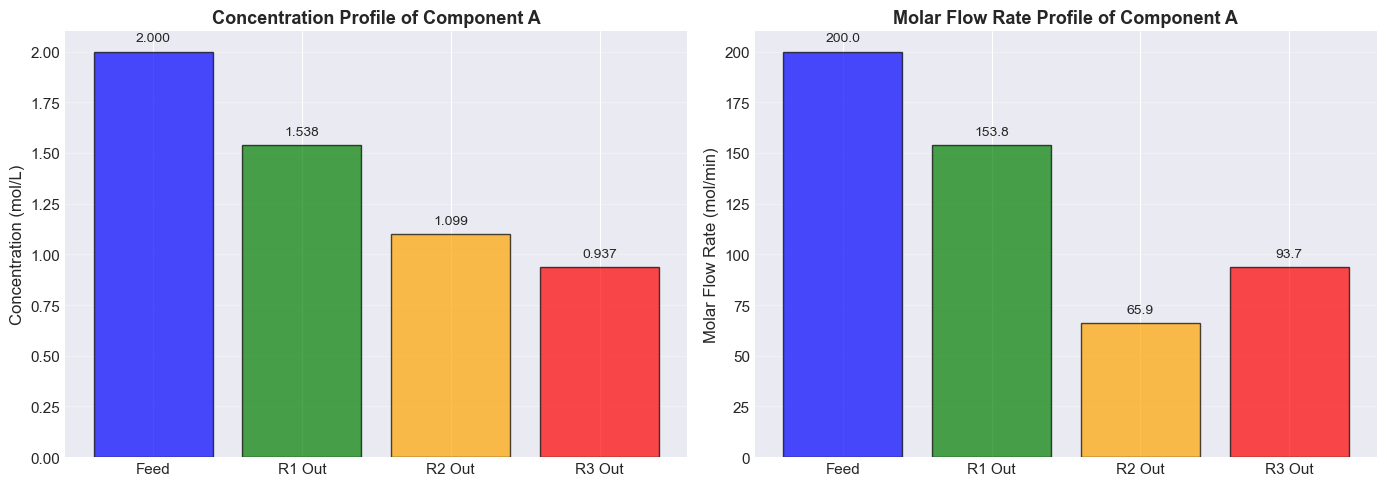

✓ 圖表已儲存至 outputs/figs/exam03_results.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 子圖 1: 濃度分布
reactors = ['Feed', 'R1 Out', 'R2 Out', 'R3 Out']
CA_values = [CA0, C_A_numpy[0], C_A_numpy[1], C_A_numpy[2]]
axes[0].bar(reactors, CA_values, color=['blue', 'green', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Concentration (mol/L)', fontsize=12)
axes[0].set_title('Concentration Profile of Component A', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (r, v) in enumerate(zip(reactors, CA_values)):
    axes[0].text(i, v + 0.05, f'{v:.3f}', ha='center', fontsize=10)

# 子圖 2: 摩爾流率分布
FA_values = [FA0, FA1, FA2, FA3]
axes[1].bar(reactors, FA_values, color=['blue', 'green', 'orange', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Molar Flow Rate (mol/min)', fontsize=12)
axes[1].set_title('Molar Flow Rate Profile of Component A', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (r, v) in enumerate(zip(reactors, FA_values)):
    axes[1].text(i, v + 5, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figs/exam03_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 圖表已儲存至 outputs/figs/exam03_results.png")

### 7.2 分流比敏感度分析圖

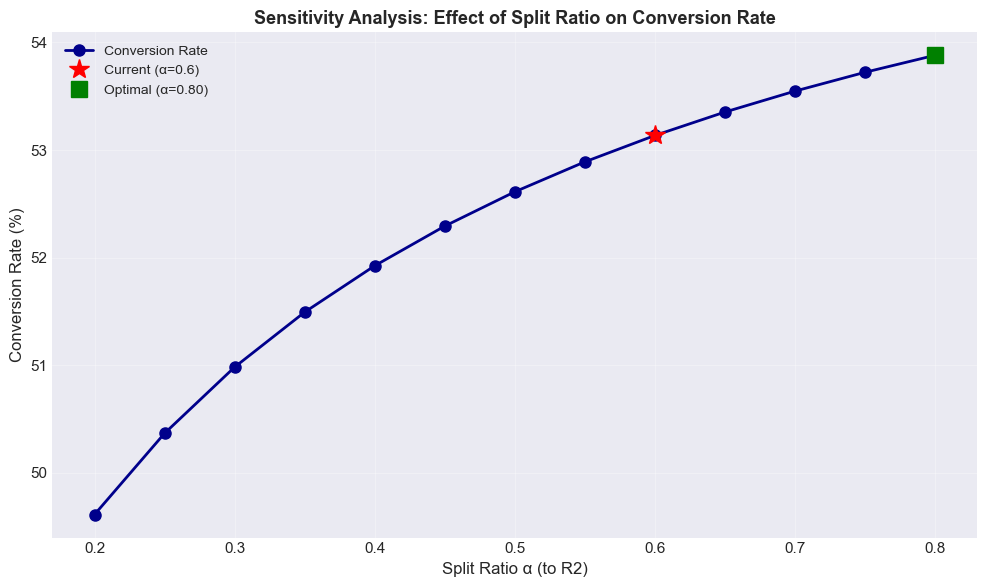

✓ 圖表已儲存至 outputs/figs/exam03_sensitivity.png


In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# 繪製轉化率隨分流比變化曲線
ax.plot(alpha_range, np.array(conversion_rates)*100, 'o-', linewidth=2, 
        markersize=8, color='darkblue', label='Conversion Rate')

# 標示當前操作點
ax.plot(alpha, conversion*100, 'r*', markersize=15, label=f'Current (α={alpha})')

# 標示最佳操作點
ax.plot(best_alpha, best_conversion*100, 'gs', markersize=12, label=f'Optimal (α={best_alpha:.2f})')

ax.set_xlabel('Split Ratio α (to R2)', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Sensitivity Analysis: Effect of Split Ratio on Conversion Rate', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figs/exam03_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 圖表已儲存至 outputs/figs/exam03_sensitivity.png")

---
## 8. 總結

### 8.1 學習要點回顧

在本範例中，我們完成了：

1. **反應器網絡物料平衡建立**：
   - 結合化學反應與物料流動的穩態平衡
   - CSTR 反應器的物料平衡方程式
   - 串並聯系統的流率分配與混合

2. **線性方程組的建立與求解**：
   - 將反應器網絡問題轉化為矩陣形式
   - 使用 NumPy 與 SciPy 求解線性方程組
   - 下三角矩陣的特性與求解

3. **結果驗證與分析**：
   - 秩判定與行列式檢查
   - 質量守恆驗證
   - 轉化率與產率計算

4. **敏感度分析**：
   - 分流比對系統性能的影響
   - 最佳操作條件的確定

### 8.2 主要結論

- 系統總轉化率： **53.14%**
- 與單一反應器相比，串並聯配置提升轉化率約 **5.77 個百分點**
- 當前分流比 (α = 0.6) 接近最佳值
- 矩陣條件良好，數值求解穩定可靠

### 8.3 實際應用

反應器網絡物料平衡廣泛應用於：
- 化工製程設計與優化
- 生化反應工程
- 環境工程
- 石油化工製程

---

**本範例完成**